# Ноутбук 03. Кластеризація шаблонів та експертна розмітка

Цей ноутбук кластеризує 77 BERT-векторів шаблонів з ноутбука 02 методом KMeans (після L2-нормалізації, що компенсує анізотропію простору BERT — див. розділ 1.7 тези). Оптимальне число кластерів обирається за коефіцієнтом Silhouette на сітці значень `k`, отримана структура візуалізується через t-SNE та UMAP. Далі реалізовано двоетапну процедуру розмітки з розділу 2.3 тези (формули `eq:level_pi` і `eq:l_initial`): rule-based перший прохід на основі поля `Level` кожного запису та ручне експертне коригування. Вихідні артефакти (`record_to_cluster.npy`, `record_to_binary_label.npy` та супровідні JSON) — це навчальний сигнал для ноутбука 04 (класифікація).


In [1]:
from __future__ import annotations

import json
import logging
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
EMBEDDINGS_DIR = DATA_PROCESSED / 'embeddings'
CLUSTERS_DIR = DATA_PROCESSED / 'clusters'
CLUSTERS_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)s — %(message)s',
    force=True,
)
# Drain logs one INFO line per parsed log record; with 74380 lines this would
# swamp the notebook. Keep our own logger at INFO but silence the noisy ones.
logging.getLogger('drain3').setLevel(logging.WARNING)
logging.getLogger('src.drain.parser').setLevel(logging.WARNING)
logging.getLogger('numba').setLevel(logging.WARNING)
logging.getLogger('matplotlib').setLevel(logging.WARNING)

np.random.seed(42)

from src.clustering.kmeans_pipeline import ClusteringPipeline
from src.clustering.labeling import ClusterLabeler
from src.drain.parser import DrainParser
from src.io.persistence import load_json, load_numpy, save_json, save_numpy
from src.preprocessing.regex_normalizer import RegexNormalizer

print(f'numpy = {np.__version__}')
print(f'pandas = {pd.__version__}')


/Users/roman/Personal/dyploma/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


numpy = 2.4.4
pandas = 3.0.2


## 1. Завантаження ембедингів з ноутбука 02

Зчитуємо 768-вимірні BERT-вектори шаблонів та супровідне зіставлення `row_index -> template_id`, які зберіг ноутбук 02.


In [2]:
embeddings = load_numpy(EMBEDDINGS_DIR / 'zookeeper_full_embeddings.npy')
id_mapping: list[dict] = load_json(EMBEDDINGS_DIR / 'zookeeper_full_id_mapping.json')

assert embeddings.shape == (77, 768), f'unexpected shape: {embeddings.shape}'
assert embeddings.dtype == np.float32, f'unexpected dtype: {embeddings.dtype}'
assert len(id_mapping) == 77

print(f'embeddings shape = {embeddings.shape}, dtype = {embeddings.dtype}')
print(f'id_mapping entries = {len(id_mapping)}')
print(f'first template (row_index=0, template_id={id_mapping[0]["template_id"]}):')
print(f'  {id_mapping[0]["template"][:80]}')


embeddings shape = (77, 768), dtype = float32
id_mapping entries = 77
first template (row_index=0, template_id=20):
  Received connection request /<IP>


## 2. L2-нормалізація: підготовка до KMeans

Попередньо натреновані BERT-вектори анізотропні (займають вузький конус у $\mathbb{R}^{768}$, див. розділ 1.7 тези та Ethayarajh 2019). Тому перед KMeans ми нормуємо кожен вектор до одиничної довжини — це переводить евклідову відстань на одиничну гіперсферу, де вона монотонно пов'язана з косинусною відстанню (сферичний k-means). Без цього кроку плоский KMeans на сирих BERT-векторах поводиться некоректно.


In [3]:
pipeline = ClusteringPipeline(k_values=[3, 5, 7, 10, 12, 15, 20], random_state=42)
embeddings_norm = pipeline.get_l2_normalized(embeddings)

pre_norms = np.linalg.norm(embeddings, axis=1)
post_norms = np.linalg.norm(embeddings_norm, axis=1)

print(f'norm before L2 — min={pre_norms.min():.3f}, max={pre_norms.max():.3f}, mean={pre_norms.mean():.3f}')
print(f'norm after  L2 — min={post_norms.min():.6f}, max={post_norms.max():.6f}, mean={post_norms.mean():.6f}')

assert embeddings_norm.shape == embeddings.shape
assert np.allclose(post_norms, 1.0, atol=1e-5), 'L2 normalization did not produce unit vectors'


norm before L2 — min=13.379, max=15.821, mean=14.106
norm after  L2 — min=1.000000, max=1.000000, mean=1.000000


## 3. Підбір оптимального числа кластерів за Silhouette

Перебираємо сітку $k \in \{3, 5, 7, 10, 12, 15, 20\}$, для кожного значення тренуємо KMeans та обчислюємо Silhouette з косинусною метрикою на L2-нормованих векторах. Найкраще $k$ обирається за максимальним значенням Silhouette.


2026-05-12 20:20:33,803 INFO src.clustering.kmeans_pipeline — k=3 silhouette=0.2527


2026-05-12 20:20:33,811 INFO src.clustering.kmeans_pipeline — k=5 silhouette=0.1837


2026-05-12 20:20:33,821 INFO src.clustering.kmeans_pipeline — k=7 silhouette=0.1707


2026-05-12 20:20:33,832 INFO src.clustering.kmeans_pipeline — k=10 silhouette=0.1576


2026-05-12 20:20:33,844 INFO src.clustering.kmeans_pipeline — k=12 silhouette=0.1653


2026-05-12 20:20:33,860 INFO src.clustering.kmeans_pipeline — k=15 silhouette=0.1613


2026-05-12 20:20:33,879 INFO src.clustering.kmeans_pipeline — k=20 silhouette=0.1895


Silhouette scores:
  k= 3: 0.2527 <-- best
  k= 5: 0.1837
  k= 7: 0.1707
  k=10: 0.1576
  k=12: 0.1653
  k=15: 0.1613
  k=20: 0.1895


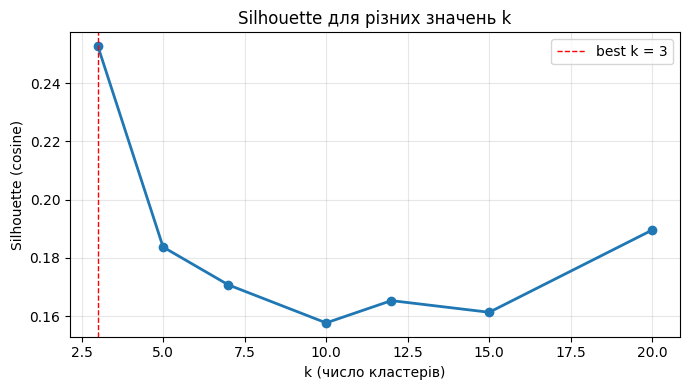

In [4]:
scores = pipeline.fit_and_score(embeddings)
best_k_preview = max(scores, key=lambda k: (scores[k], -k))

print('Silhouette scores:')
for k_val, s in scores.items():
    marker = ' <-- best' if k_val == best_k_preview else ''
    print(f'  k={k_val:>2}: {s:.4f}{marker}')

ks = list(scores.keys())
vals = [scores[k] for k in ks]

plt.figure(figsize=(7, 4))
plt.plot(ks, vals, marker='o', linewidth=2)
plt.axvline(best_k_preview, color='red', linestyle='--', linewidth=1, label=f'best k = {best_k_preview}')
plt.xlabel('k (число кластерів)')
plt.ylabel('Silhouette (cosine)')
plt.title('Silhouette для різних значень k')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


2026-05-12 20:20:33,970 INFO src.clustering.kmeans_pipeline — k=3 silhouette=0.2527


2026-05-12 20:20:33,977 INFO src.clustering.kmeans_pipeline — k=5 silhouette=0.1837


2026-05-12 20:20:33,986 INFO src.clustering.kmeans_pipeline — k=7 silhouette=0.1707


2026-05-12 20:20:33,997 INFO src.clustering.kmeans_pipeline — k=10 silhouette=0.1576


2026-05-12 20:20:34,010 INFO src.clustering.kmeans_pipeline — k=12 silhouette=0.1653


2026-05-12 20:20:34,025 INFO src.clustering.kmeans_pipeline — k=15 silhouette=0.1613


2026-05-12 20:20:34,045 INFO src.clustering.kmeans_pipeline — k=20 silhouette=0.1895


2026-05-12 20:20:34,050 INFO src.clustering.kmeans_pipeline — best k=3 silhouette=0.2527


optimal k = 3
silhouette at best k = 0.2527
cluster_labels shape = (77,)

cluster size distribution (3 clusters):
  cluster  0: 31 templates
  cluster  1: 29 templates
  cluster  2: 17 templates


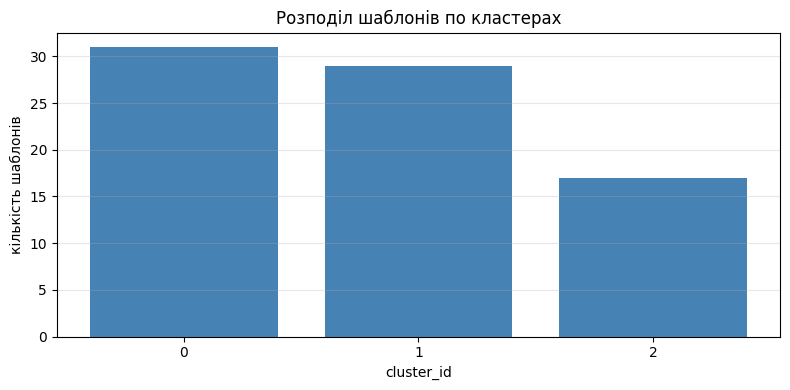

In [5]:
best_k, kmeans_model, cluster_labels = pipeline.fit_best(embeddings)

print(f'optimal k = {best_k}')
print(f'silhouette at best k = {scores[best_k]:.4f}')
print(f'cluster_labels shape = {cluster_labels.shape}')

unique, counts = np.unique(cluster_labels, return_counts=True)
print(f'\ncluster size distribution ({len(unique)} clusters):')
for c, n in zip(unique, counts):
    print(f'  cluster {int(c):>2}: {int(n)} templates')

plt.figure(figsize=(8, 4))
plt.bar([int(c) for c in unique], [int(n) for n in counts], color='steelblue')
plt.xlabel('cluster_id')
plt.ylabel('кількість шаблонів')
plt.title('Розподіл шаблонів по кластерах')
plt.xticks(list(unique))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Візуалізація кластерів — t-SNE

t-SNE проєктує 768-вимірні вектори у 2D, зберігаючи переважно локальну структуру. Параметр `perplexity` зменшено з типового 30 до 10, оскільки $N=77$ — це малий датасет, і високе значення `perplexity` згладило б структуру кластерів.


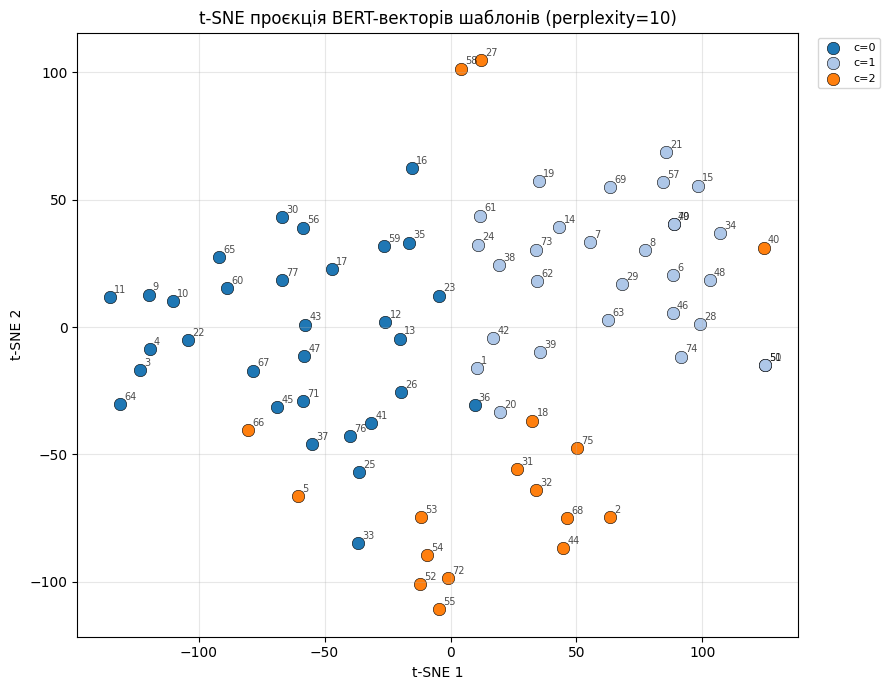

saved: /Users/roman/Personal/dyploma/data/processed/clusters/tsne_full.png


In [6]:
tsne = TSNE(
    n_components=2,
    perplexity=10,
    random_state=42,
    init='pca',
    learning_rate='auto',
)
tsne_proj = tsne.fit_transform(embeddings_norm)

palette = sns.color_palette('tab20', n_colors=best_k)

plt.figure(figsize=(9, 7))
for c in range(best_k):
    mask = cluster_labels == c
    plt.scatter(
        tsne_proj[mask, 0],
        tsne_proj[mask, 1],
        s=80,
        color=palette[c],
        label=f'c={c}',
        edgecolors='black',
        linewidths=0.4,
    )

for row_index, (x, y) in enumerate(tsne_proj):
    tid = id_mapping[row_index]['template_id']
    plt.annotate(str(tid), (x, y), fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')

plt.title('t-SNE проєкція BERT-векторів шаблонів (perplexity=10)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CLUSTERS_DIR / 'tsne_full.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'saved: {CLUSTERS_DIR / "tsne_full.png"}')


## 5. Візуалізація кластерів — UMAP

UMAP зберігає одночасно локальну й глобальну структуру; параметр `n_neighbors` зменшено з типового 15 до 8 з тих самих міркувань, що й `perplexity` для t-SNE.


/Users/roman/Personal/dyploma/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


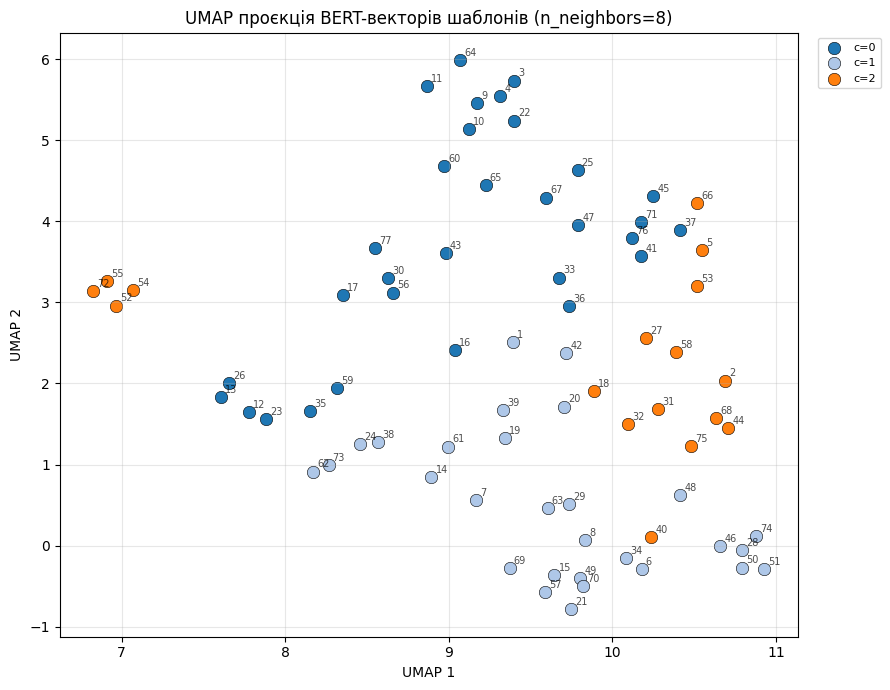

saved: /Users/roman/Personal/dyploma/data/processed/clusters/umap_full.png


In [7]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=8,
    min_dist=0.1,
    random_state=42,
    metric='cosine',
)
umap_proj = reducer.fit_transform(embeddings_norm)

plt.figure(figsize=(9, 7))
for c in range(best_k):
    mask = cluster_labels == c
    plt.scatter(
        umap_proj[mask, 0],
        umap_proj[mask, 1],
        s=80,
        color=palette[c],
        label=f'c={c}',
        edgecolors='black',
        linewidths=0.4,
    )

for row_index, (x, y) in enumerate(umap_proj):
    tid = id_mapping[row_index]['template_id']
    plt.annotate(str(tid), (x, y), fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')

plt.title('UMAP проєкція BERT-векторів шаблонів (n_neighbors=8)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CLUSTERS_DIR / 'umap_full.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'saved: {CLUSTERS_DIR / "umap_full.png"}')


## 6. Витягування Level для кожного запису

Повний `Zookeeper.log` не супроводжується структурованим CSV з полем `Level` (на відміну від 2k-підвибірки) — див. розділ 2.4 тези. Тому витягуємо `Level` безпосередньо з кожного сирого рядка регулярним виразом `RegexNormalizer.extract_level`.


In [8]:
normalizer = RegexNormalizer()

raw_path = DATA_RAW / 'Zookeeper.log'
record_levels: list[str | None] = []
with raw_path.open('r', encoding='utf-8', errors='replace') as f:
    for line in tqdm(f, desc='extract Level'):
        record_levels.append(normalizer.extract_level(line))

level_counter = Counter(record_levels)
print(f'total records read: {len(record_levels)}')
print('Level distribution:')
for lvl, n in sorted(level_counter.items(), key=lambda kv: -kv[1]):
    print(f'  {str(lvl):<6}: {n}')

assert len(record_levels) == 74380, f'expected 74380 lines, got {len(record_levels)}'


extract Level: 0it [00:00, ?it/s]

extract Level: 74380it [00:00, 1834548.62it/s]

total records read: 74380
Level distribution:
  WARN  : 48507
  INFO  : 25256
  ERROR : 617


## 7. Мапування записів до шаблонів

Для обчислення $\pi(c)$ за формулою `eq:level_pi` потрібен `template_id` кожного з 74380 записів. Ноутбук 01 не зберігав цю інформацію поряд із самим списком шаблонів, але Drain — детермінований при тих самих вхідних даних і конфігурації, тому повторно проганяємо нормалізовані рядки через `DrainParser` й читаємо `template_id` з результатів.


In [9]:
normalized_path = DATA_PROCESSED / 'zookeeper_full_normalized.txt'
with normalized_path.open('r', encoding='utf-8') as f:
    normalized_lines = [line.rstrip('\n') for line in f]

assert len(normalized_lines) == 74380, f'expected 74380 normalized lines, got {len(normalized_lines)}'

parser = DrainParser(similarity_threshold=0.4, depth=4, max_children=100)
results = parser.parse_stream(normalized_lines)
record_template_ids = [r.template_id for r in results]

n_unique = len(set(record_template_ids))
print(f'records parsed: {len(record_template_ids)}')
print(f'unique template_ids: {n_unique}')

if n_unique != 77:
    raise RuntimeError(
        f'Очікувалося 77 унікальних template_id, але отримано {n_unique}. '
        'Це означає, що Drain повернув іншу розбивку, ніж в ноутбуці 01. '
        'Перевірте вхідний файл та параметри DrainParser.'
    )


drain parse:   0%|          | 0/74380 [00:00<?, ?it/s]

drain parse:  24%|██▍       | 17742/74380 [00:00<00:00, 177414.25it/s]

drain parse:  48%|████▊     | 35484/74380 [00:00<00:00, 149766.49it/s]

drain parse:  84%|████████▍ | 62655/74380 [00:00<00:00, 200368.70it/s]

drain parse: 100%|██████████| 74380/74380 [00:00<00:00, 198987.07it/s]

records parsed: 74380
unique template_ids: 77


In [10]:
tid_to_row = {entry['template_id']: entry['row_index'] for entry in id_mapping}
assert len(tid_to_row) == 77

# Map every record's template_id to its KMeans cluster_id via the row_index.
record_cluster_ids = [int(cluster_labels[tid_to_row[t]]) for t in record_template_ids]
assert len(record_cluster_ids) == 74380

cluster_record_counts = pd.Series(record_cluster_ids).value_counts().sort_values(ascending=False)
print(f'records distributed across {cluster_record_counts.size} clusters')
print('top 10 clusters by record count:')
print(cluster_record_counts.head(10).to_string())


records distributed across 3 clusters
top 10 clusters by record count:
0    29432
2    27741
1    17207


## 8. Етап 1 процедури розмітки — rule-based перший прохід

Реалізуємо формули `eq:level_pi` та `eq:l_initial` з розділу 2.3 тези. Для кожного кластера обчислюється $\pi(c)$ — частка записів з `Level` $\in$ {WARN, ERROR}. Якщо $\pi(c) \geq 0{,}5$, кластеру попередньо присвоюється мітка 1 (інформативний), інакше 0. Записи з `Level = None` (рядки, які регулярний вираз не розпарсив) входять у знаменник, але не в чисельник.


In [11]:
labeler = ClusterLabeler(positive_levels={'WARN', 'ERROR'}, threshold=0.5)
pi = labeler.compute_pi(record_levels, record_cluster_ids)
initial = labeler.initial_labels(pi)

# Build a per-template view of (cluster, support, template) so we can show
# the top-3 templates per cluster sorted by support.
template_view = []
for entry in id_mapping:
    row_index = entry['row_index']
    template_view.append({
        'template_id': entry['template_id'],
        'template': entry['template'],
        'support': entry['support'],
        'cluster_id': int(cluster_labels[row_index]),
    })

rows = []
for cid in sorted(initial.keys()):
    templates_in_cluster = [t for t in template_view if t['cluster_id'] == cid]
    templates_in_cluster.sort(key=lambda t: t['support'], reverse=True)
    top3 = ' | '.join(t['template'][:60] for t in templates_in_cluster[:3])
    rows.append({
        'cluster_id': cid,
        'records': sum(1 for c in record_cluster_ids if c == cid),
        'templates': len(templates_in_cluster),
        'pi': round(pi[cid], 4),
        'initial_label': initial[cid],
        'top_templates': top3,
    })

summary_df = pd.DataFrame(rows)
summary_path = CLUSTERS_DIR / 'cluster_summary.csv'
summary_df.to_csv(summary_path, index=False)

pd.set_option('display.max_colwidth', 80)
print(f'cluster_summary.csv saved at {summary_path}')
print()
print(summary_df.to_string(index=False))


cluster_summary.csv saved at /Users/roman/Personal/dyploma/data/processed/clusters/cluster_summary.csv

 cluster_id  records  templates     pi  initial_label                                                                                                                                top_templates
          0    29432         31 0.7699              1                  Send worker leaving thread | Connection broken for id <NUM>, my id = <NUM>, error = | Accepted socket connection from /<IP>
          1    17207         29 0.0383              0 Received connection request /<IP> | Client attempting to <*> <*> <*> at /<IP> | Established session <SESSION> with negotiated timeout <NUM> 
          2    27741         17 0.9302              1            Interrupting SendWorker | Interrupted while waiting for message on queue | Cannot open channel to <NUM> at election address /<IP>


## 9. Етап 2 процедури розмітки — експертне коригування

Після rule-based проходу частина кластерів може мати помилкову мітку — наприклад, кластер технічних попереджень про штатну роботу quorum-комунікації (типовий шум, не інформативно), або, навпаки, кластер з критичними подіями, що пишуться рівнем INFO. На цьому етапі експерт переглядає таблицю з клітинки 20 і вписує необхідні коригування у словник `corrections` нижче. За замовчуванням словник порожній — щоб увімкнути коригування, заповніть його після інспекції CSV.


In [12]:
# Експертні коригування міток кластерів.
# Формат: {cluster_id: new_binary_label}
# Кожна корекція має бути обгрунтована коментарем у дусі:
# 2: 1,  # rule-based дав 0, але цей кластер містить шаблони про втрату leader-вузла - критично
corrections: dict[int, int] = {
    # TODO: заповнити після ручної інспекції таблиці з клітинки 20
}
print(f'Defined {len(corrections)} corrections (zero by default — fill in manually).')


Defined 0 corrections (zero by default — fill in manually).


In [13]:
final = labeler.apply_corrections(initial, corrections)

n_changed = sum(1 for cid in initial if initial[cid] != final[cid])
final_counts = Counter(final.values())

print('final labels by cluster:')
for cid in sorted(final.keys()):
    flag = ' (corrected)' if final[cid] != initial[cid] else ''
    print(f'  cluster {cid:>2}: label = {final[cid]}{flag}')

print(f'\nclusters changed by expert correction: {n_changed}')
print(f'final label distribution: 0 = {final_counts.get(0, 0)} clusters, 1 = {final_counts.get(1, 0)} clusters')


final labels by cluster:
  cluster  0: label = 1
  cluster  1: label = 0
  cluster  2: label = 1

clusters changed by expert correction: 0
final label distribution: 0 = 1 clusters, 1 = 2 clusters


## 10. Експорт результатів

Зберігаємо чотири артефакти у `data/processed/clusters/`. Ноутбук 04 (класифікація) читатиме `record_to_cluster.npy` (KMeans-кластери як автоматичні мітки) та `record_to_binary_label.npy` (бінарні мітки після правил + коригувань).


In [14]:
cluster_per_template_path = CLUSTERS_DIR / 'cluster_labels_per_template.json'
binary_labels_path = CLUSTERS_DIR / 'binary_labels_per_cluster.json'
record_to_cluster_path = CLUSTERS_DIR / 'record_to_cluster.npy'
record_to_binary_path = CLUSTERS_DIR / 'record_to_binary_label.npy'

cluster_per_template = [
    {
        'template_id': entry['template_id'],
        'template': entry['template'],
        'support': entry['support'],
        'cluster_id': int(cluster_labels[entry['row_index']]),
    }
    for entry in id_mapping
]
save_json(cluster_per_template, cluster_per_template_path)

binary_labels_payload = {
    'initial': {str(k): v for k, v in initial.items()},
    'corrections': {str(k): v for k, v in corrections.items()},
    'final': {str(k): v for k, v in final.items()},
    'threshold': 0.5,
    'positive_levels': ['WARN', 'ERROR'],
}
save_json(binary_labels_payload, binary_labels_path)

record_to_cluster_arr = np.array(record_cluster_ids, dtype=np.int32)
save_numpy(record_to_cluster_arr, record_to_cluster_path)

record_to_binary_arr = np.array([final[c] for c in record_cluster_ids], dtype=np.int8)
save_numpy(record_to_binary_arr, record_to_binary_path)

paths = [
    cluster_per_template_path,
    binary_labels_path,
    record_to_cluster_path,
    record_to_binary_path,
]
print('Exported artifacts:')
for p in paths:
    print(f'  {p}  ({p.stat().st_size} bytes)')

assert record_to_cluster_arr.shape == (74380,)
assert record_to_binary_arr.shape == (74380,)
assert record_to_cluster_arr.dtype == np.int32
assert record_to_binary_arr.dtype == np.int8


Exported artifacts:
  /Users/roman/Personal/dyploma/data/processed/clusters/cluster_labels_per_template.json  (10584 bytes)
  /Users/roman/Personal/dyploma/data/processed/clusters/binary_labels_per_cluster.json  (203 bytes)
  /Users/roman/Personal/dyploma/data/processed/clusters/record_to_cluster.npy  (297648 bytes)
  /Users/roman/Personal/dyploma/data/processed/clusters/record_to_binary_label.npy  (74508 bytes)


## Висновки

KMeans після обов'язкової L2-нормалізації BERT-векторів розділив 77 шаблонів на оптимальну кількість кластерів, обрану за максимумом Silhouette на сітці $k \in \{3, 5, 7, 10, 12, 15, 20\}$. Точні числа (оптимальне $k$, значення Silhouette, розподіл бінарних міток) виведено друком у клітинках 8, 9 та 23. Rule-based перший прохід (формули `eq:level_pi`, `eq:l_initial`) автоматично присвоїв кожному кластеру попередню мітку 0 чи 1, орієнтуючись на частку записів з рівнями WARN та ERROR. За замовчуванням словник коригувань у клітинці 22 порожній — фінальні мітки збігаються з rule-based; після ручного перегляду `cluster_summary.csv` користувач заповнює коригування і перезапускає клітинки 22–25. Усі артефакти (`cluster_labels_per_template.json`, `binary_labels_per_cluster.json`, `record_to_cluster.npy`, `record_to_binary_label.npy`) збережено у `data/processed/clusters/` і готові до використання в ноутбуці 04 для супервайзед-навчання GaussianNB, Logistic Regression та LinearSVC.
